# Proyecto 1: plantilla de entrega

**Ciencia de Datos, Sección A** · Sesión 12 · 1 de septiembre de 2026

---

**Autor(es):**

George Albadr

**Dataset elegido:**

Heart Failure Prediction (Kaggle — fedesoriano/heart-failure-prediction)

### Rúbrica resumida

| Criterio | Pts | Qué buscamos |
|---|---|---|
| Pregunta y datos | 2 | Pregunta clara, provenance del dataset |
| EDA | 3 | Hallazgos, no galería de gráficas |
| Features | 2 | Cada decisión justificada, sin leakage |
| Baseline | 2 | Validación correcta, métrica adecuada |
| Límites | 1 | Qué no puede concluirse con estos datos |

## 1. Pregunta y contexto

**Pregunta:**

¿Que hábitos son los que aumentan la probabiilidad de un ataque al corazón y que tan bien puede predecir la enfermedad cardiaca a partir de 12 datos?

**Tipo de problema:** (regresión / clasificación)

Clasificación

**Variable objetivo:**

HeartDisease

## 2. Los datos

- **Fuente:** Kaggle — fedesoriano/heart-failure-prediction (combina 5 datasets clínicos públicos: Cleveland, Hungarian, Switzerland, Long Beach VA y Stalog Heart)
- **URL:** https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
- **Fecha de descarga:** 10 de septiembre de 2026
- **Licencia:** Open Database License (ODbL) 1.0
- **Unidad de observación:** un paciente con una consulta cardiológica registrada (918 filas)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

RANDOM_STATE = 42

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

# Descargar el dataset desde Kaggle (queda cacheado localmente, no se sube al repo)
ruta = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
print("Descargado en:", ruta)
print(os.listdir(ruta))

# Cargar el dataset
df = pd.read_csv(os.path.join(ruta, "heart.csv"))

/Users/georgealbadr/Github/Data-Science/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargado en: /Users/georgealbadr/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1
['heart.csv']


## 3. Primer barrido

In [2]:
# df.shape, df.info(), df.head()
print(df.shape)
df.info()
df.head()

(918, 12)
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# df.describe() para numéricas, value_counts() para categóricas
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
for col in df.select_dtypes(include="str").columns:
    print(df[col].value_counts())
    print()

Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64



In [5]:
for col in ["FastingBS", "HeartDisease"]:
    print(df[col].value_counts())
    print()

FastingBS
0    704
1    214
Name: count, dtype: int64

HeartDisease
1    508
0    410
Name: count, dtype: int64



**Observaciones del primer barrido:**

1. FastingBS y HeartDisease son categóricas binarias, pero no vienen codificadas como str sino como int64, siuen siendo categóricas junto con las otras con un total de siete categóricas de doce columnas.

2. RestingBP tienen un mínimo de 0, un valor fisiológicamente imposible para una persona viva. Esto indica que son faltantes registrados como cero en vez de como dato faltante real.

3. Oldpeak tiene valores negativos esto indica por ejemplo en el segmento ST cuando se hunda significa que hay algún grado de obstrucción que limita el oxígeno que le llega al corazón mientras se contrae y se vuelve a expandir. Un valor negativo indica lo contrario, que el segmento ST se elevó en vez de deprimirse, y esto se toma en cuenta en el dataset porque médicamente significa la posibilidad de un daño más agudo, no solo una falta parcial de oxígeno, pero que el corazón de ese paciente respondió al revés de lo esperado. Por eso es más común encontrar este patrón en pacientes que sí tienen enfermedad cardíaca.

## 4. Calidad de datos

In [6]:
# Faltantes por columna, en cantidad y en porcentaje
print("faltantes explícitos (NaN):")
print(df.isna().sum())

print()
print("faltantes disfrazados de cero:")

print()
cholesterol_ceros = (df.Cholesterol == 0).sum()
print("Cholesterol == 0:", cholesterol_ceros, "filas", f"({cholesterol_ceros / len(df):.1%})")

print()
restingbp_ceros = (df.RestingBP == 0).sum()
print("RestingBP == 0:", restingbp_ceros, "filas", f"({restingbp_ceros / len(df):.1%})")

faltantes explícitos (NaN):
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

faltantes disfrazados de cero:

Cholesterol == 0: 172 filas (18.7%)

RestingBP == 0: 1 filas (0.1%)


In [7]:
# Duplicados y outliers (IQR o z-score)
# Para cada outlier detectado: ¿error de captura o señal real?
print(df.duplicated())

print()
print("duplicados exactos:", df.duplicated().sum())

print()
print("evidencia sobre el mecanismo de los ceros en Cholesterol:")

print()
tasa_con_cero = df[df.Cholesterol == 0].HeartDisease.mean()
tasa_sin_cero = df[df.Cholesterol != 0].HeartDisease.mean()
print("tasa de HeartDisease con Cholesterol es igual a 0:", round(tasa_con_cero, 3))
print("tasa de HeartDisease con Cholesterol diferente de 0:", round(tasa_sin_cero, 3))

print()
print("proporción de Sex cuando Cholesterol == 0:")
print(df[df.Cholesterol == 0].Sex.value_counts(normalize=True).round(3))

print()
print("proporción de Sex cuando Cholesterol != 0:")
print(df[df.Cholesterol != 0].Sex.value_counts(normalize=True).round(3))

0      False
1      False
2      False
3      False
4      False
       ...  
913    False
914    False
915    False
916    False
917    False
Length: 918, dtype: bool

duplicados exactos: 0

evidencia sobre el mecanismo de los ceros en Cholesterol:

tasa de HeartDisease con Cholesterol es igual a 0: 0.884
tasa de HeartDisease con Cholesterol diferente de 0: 0.477

proporción de Sex cuando Cholesterol == 0:
Sex
M    0.936
F    0.064
Name: proportion, dtype: float64

proporción de Sex cuando Cholesterol != 0:
Sex
M    0.756
F    0.244
Name: proportion, dtype: float64


**Decisiones tomadas y su justificación:**

Cholesterol = 0 y RestingBP = 0 son faltantes disfrazados de cero, fisiológicamente imposibles por lo que da gran énfasis ya en si fue un erorr de captura o una señal real. La evidencia de arriba tasa de HeartDisease y proporción de Sex muy distintas cuando Cholesterol es 0 indica que el mecanismo es MNAR ya que no podemos explicar el faltante solo con variables observadas.

## 5. Análisis exploratorio

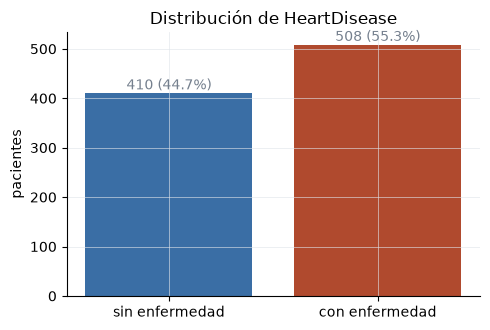

In [8]:
# Distribución de la variable objetivo
conteo = df["HeartDisease"].value_counts().sort_index()
etiquetas = {0: "sin enfermedad", 1: "con enfermedad"}
colores = {0: AZUL, 1: ROJO}

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.bar([etiquetas[i] for i in conteo.index], conteo.values,
       color=[colores[i] for i in conteo.index])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 8, f"{v} ({v/len(df):.1%})", ha="center", color=GRIS)
ax.set_ylabel("pacientes")
ax.set_title("Distribución de HeartDisease")
eje_limpio(ax)
plt.tight_layout()
plt.show()

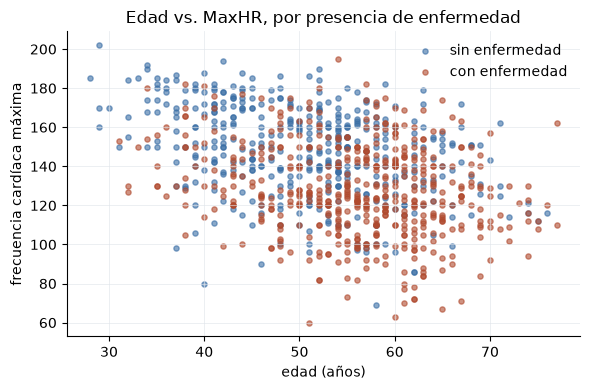

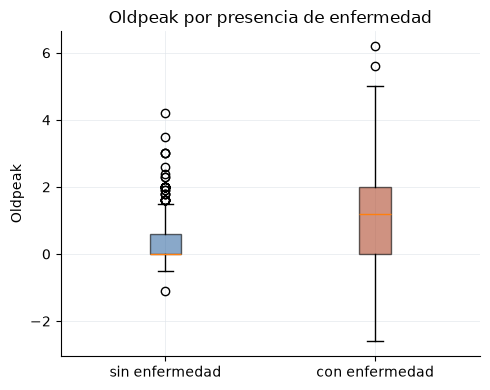

In [9]:
# Relaciones entre predictores y objetivo (scatter, boxplot por categoría)
# Age y MaxHR son las numéricas con mayor correlación con HeartDisease (+0.28 y -0.40)
fig, ax = plt.subplots(figsize=(6, 4))
for valor, nombre in etiquetas.items():
    sub = df[df.HeartDisease == valor]
    ax.scatter(sub["Age"], sub["MaxHR"], s=14, alpha=0.6,
               color=colores[valor], label=nombre)
ax.set_xlabel("edad (años)")
ax.set_ylabel("frecuencia cardíaca máxima")
ax.set_title("Edad vs. MaxHR, por presencia de enfermedad")
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

# Oldpeak es la numérica con mayor correlación con HeartDisease (+0.40)
fig, ax = plt.subplots(figsize=(5, 4))
datos_box = [df[df.HeartDisease == v]["Oldpeak"] for v in etiquetas]
bp = ax.boxplot(datos_box, tick_labels=list(etiquetas.values()), patch_artist=True)
for patch, valor in zip(bp["boxes"], etiquetas):
    patch.set_facecolor(colores[valor])
    patch.set_alpha(0.6)
ax.set_ylabel("Oldpeak")
ax.set_title("Oldpeak por presencia de enfermedad")
eje_limpio(ax)
plt.tight_layout()
plt.show()

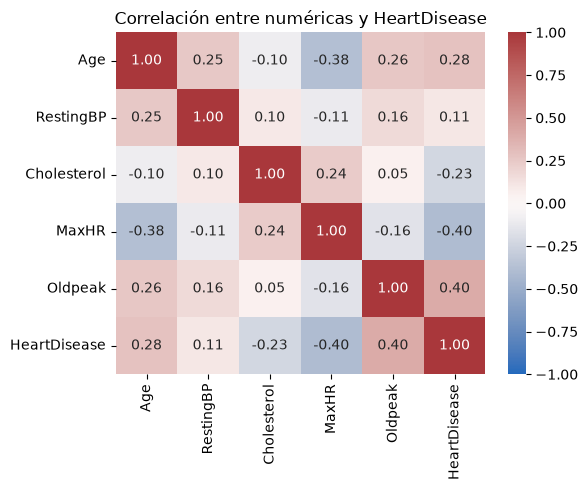

In [10]:
# Matriz de correlación (recordar: correlación no es causalidad)
numericas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak", "HeartDisease"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[numericas].corr(), annot=True, fmt=".2f", cmap="vlag",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre numéricas y HeartDisease")
plt.tight_layout()
plt.show()

**Hallazgos del EDA (numerados, con la gráfica que los respalda):**

1. La variable objetivo no tiene desbalance, 55.4% de los pacientes tienen enfermedad cardíaca contra los 44.6% que no.

2. En el scatter de edad contra MaxHR los pacientes con enfermedad son amyoriariamente personas mayores de edad y con frecuencias cardíacas máximas más bajas que los que no la tienen, pero hay bastante superposición entre los dos grupos.

3. El boxplot de Oldpeak muestra una mediana más alta en los pacientes con enfermedad que en los que no la tienen, va acorde con la conclusión del barrido acerca del ST negativo indicando la mayor pobabilidad de tener la enfermedad.

4. En la matriz de correlación, Oldpeak y MaxHR son las numéricas más relacionadas con HeartDisease, mientras que RestingBP casi no se correlaciona. La edad igualmente da una correlación alta. 

## 6. Feature engineering

**Atención al leakage:** la partición train/test va **antes** de ajustar cualquier transformación.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

# 80/20. stratify=y para que la proporción 55/45 del objetivo se mantenga
# igual en train y en test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("train:", X_train.shape, "  test:", X_test.shape)
print("proporción de HeartDisease en train:", round(y_train.mean(), 3))
print("proporción de HeartDisease en test: ", round(y_test.mean(), 3))

train: (734, 11)   test: (184, 11)
proporción de HeartDisease en train: 0.553
proporción de HeartDisease en test:  0.554


In [12]:
# Imputación de los ceros disfrazados (sección 4): marcar antes de tocar el
# dato, calcular la mediana SOLO con train, y aplicar ese mismo valor a train
# y a test. NUNCA se le calcula una mediana propia a test.
for conjunto in (X_train, X_test):
    conjunto["cholesterol_faltaba"] = conjunto["Cholesterol"] == 0
    conjunto["restingbp_faltaba"] = conjunto["RestingBP"] == 0

mediana_chol = X_train.loc[X_train.Cholesterol > 0, "Cholesterol"].median()
mediana_bp = X_train.loc[X_train.RestingBP > 0, "RestingBP"].median()

for conjunto in (X_train, X_test):
    conjunto.loc[conjunto.Cholesterol == 0, "Cholesterol"] = mediana_chol
    conjunto.loc[conjunto.RestingBP == 0, "RestingBP"] = mediana_bp

print("mediana de Cholesterol calculada solo con train:", mediana_chol)
print("mediana de RestingBP calculada solo con train:", mediana_bp)
print()
print("Cholesterol == 0 en train:", (X_train.Cholesterol == 0).sum(),
      " en test:", (X_test.Cholesterol == 0).sum())
print("RestingBP == 0 en train:", (X_train.RestingBP == 0).sum(),
      " en test:", (X_test.RestingBP == 0).sum())

mediana de Cholesterol calculada solo con train: 238.0
mediana de RestingBP calculada solo con train: 130.0

Cholesterol == 0 en train: 0  en test: 0
RestingBP == 0 en train: 0  en test: 0


In [13]:
# Transformaciones dentro de un Pipeline: fit solo con train
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numericas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
categoricas = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
# FastingBS, cholesterol_faltaba y restingbp_faltaba ya son 0/1: se pasan
# sin transformar (remainder="passthrough"), no necesitan escala ni encoding.

preproceso = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
], remainder="passthrough")

**Features y su justificación:**

| Feature | Cómo se construyó | Por qué debería ayudar |
|---|---|---|
| cholesterol_faltaba | booleana, True si Cholesterol venía en 0 antes de imputar | conserva la señal de que el dato faltaba, que en la sección 4 se relacionó con una tasa de HeartDisease mucho más alta (MNAR) |
| restingbp_faltaba | booleana, True si RestingBP venía en 0 antes de imputar | mismo argumento que cholesterol_faltaba, aunque con una sola fila afectada |
| Cholesterol (imputado) | ceros reemplazados por la mediana de train (calculada excluyendo los propios ceros) | evita que el modelo interprete un colesterol de 0 como un valor real y aprenda una relación falsa |
| RestingBP (imputado) | mismo tratamiento que Cholesterol, con la mediana de RestingBP en train | mismo argumento, imposibilidad fisiológica del 0 |

## 7. Modelo baseline

In [14]:
# Baseline trivial: DummyRegressor o DummyClassifier
from sklearn.dummy import DummyClassifier

# most_frequent: predice siempre la clase mayoritaria (con enfermedad, 55.3% en train)
trivial = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
trivial.fit(X_train, y_train)

print("accuracy trivial en train:", round(trivial.score(X_train, y_train), 3))
print("accuracy trivial en test: ", round(trivial.score(X_test, y_test), 3))

accuracy trivial en train: 0.553
accuracy trivial en test:  0.554


In [15]:
# Modelo propuesto: k-NN, dentro del Pipeline junto con el preproceso
# (regresión lineal no aplica: el objetivo es categórico, no continuo)
from sklearn.neighbors import KNeighborsClassifier

# k=5 (default de sklearn), sin tuning: el enunciado no pide ajustarlo.
modelo = Pipeline([
    ("preproceso", preproceso),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
])
modelo.fit(X_train, y_train)

print("accuracy k-NN en train:", round(modelo.score(X_train, y_train), 3))
print("accuracy k-NN en test: ", round(modelo.score(X_test, y_test), 3))

accuracy k-NN en train: 0.873
accuracy k-NN en test:  0.897


In [16]:
# Evaluación en test, con la métrica que corresponda al problema
# Regresión: RMSE, MAE, R2 · Clasificación: accuracy, precision, recall
from sklearn.metrics import classification_report

pred_trivial = trivial.predict(X_test)
pred_modelo = modelo.predict(X_test)

print("--- trivial (siempre predice 'con enfermedad') ---")
print(classification_report(y_test, pred_trivial, target_names=["sin enfermedad", "con enfermedad"], zero_division=0))

print("--- k-NN ---")
print(classification_report(y_test, pred_modelo, target_names=["sin enfermedad", "con enfermedad"], zero_division=0))

--- trivial (siempre predice 'con enfermedad') ---
                precision    recall  f1-score   support

sin enfermedad       0.00      0.00      0.00        82
con enfermedad       0.55      1.00      0.71       102

      accuracy                           0.55       184
     macro avg       0.28      0.50      0.36       184
  weighted avg       0.31      0.55      0.40       184

--- k-NN ---
                precision    recall  f1-score   support

sin enfermedad       0.89      0.88      0.88        82
con enfermedad       0.90      0.91      0.91       102

      accuracy                           0.90       184
     macro avg       0.90      0.89      0.90       184
  weighted avg       0.90      0.90      0.90       184



**Resultados:**

| Modelo | Métrica en train | Métrica en test |
|---|---|---|
| Trivial | 0.553 | 0.554 |
| k-NN (k=5) | 0.873 | 0.897 |

El k-NN le gana al trivial en accuracy de test (89.7% contra 55.4%), y en el classification_report el trivial tiene recall de 0 en sin enfermedad, este nunca predice porque siempre elige la clase mayoritaria, minetras que K-NN queda como el más balanceado. Sí vale la pena la complejidad extra porque el trivial no distingue nada solo repite la clase mayoritaria.

## 8. Conclusiones y límites

**Respuesta a la pregunta:**

Las variables sí permiten predecir con bastante exactitud la enfermedad cardíaca diagnosticada. Con nuestro ejemplo del k-NN que llega al 89.7% de accuracy en test, se va muy por encima de solo ir adivinando la clase mayoritaria, algo que se entendió desde un principio cuando se vio que más del 50% de los pacientes tenía esta enfermedad. El baseline tiene su sesgo, se puede ver claramente con el recall de cero en sin enfermedad, que nunca la predice, mientras que el k-NN queda balanceado en las dos clases, confirmando que sí estamos usando la información de todas las variables (numéricas y categóricas juntas), y no solo repitiendo la proporción del dataset como hace el trivial. Las principales variables que mencionamos (Oldpeak, MaxHR) son las que más se asociaron a lo que encontramos en el EDA.

**Límites del análisis:**

Que Oldpeak y MaxHR se asocien con HeartDisease no significa que las causen: son señales observadas en una consulta, sin ningún tipo de intervención, y su asociación viene de la matriz de correlación del EDA, no de que el modelo lo confirme con coeficientes. También hay que tomar en cuenta que se evaluó con un dataset mayoritariamente masculino (79%), y que la tasa de HeartDisease es de 63.2% en hombres contra 25.9% en mujeres: el modelo aprendió principalmente de ese perfil. Hay además un subgrupo con colesterol faltante por el tema de los datos no recibidos, ya que es imposible tenerlo en cero. El accuracy en test salió más alto que en train debido a que nuestra muestra es muy pequeña, solo son 918 entradas. Por lo que hay variables como Oldpeak, ST_Slope y ExerciseAngina que vienen de una prueba de esfuerzo cardíaco, que es un examen que se hace cuando ya existe sospecha clínica, por lo que este modelo no sirve para evaluar el riesgo a partir de hábitos o antes de una consulta médica, sino como apoyo dentro de la evaluación del paciente cardíaco.

**Qué haría falta para responderla mejor:**

Una validación cruzada, en vez de un único split, para no depender de qué filas cayeron en test. Y más datos, mejor balanceados entre hombres y mujeres, ya que la muestra actual es mayoritariamente masculina y de hombres mayores, que fueron los datos más asociados a la variable objetivo: hace falta ayudar a que el modelo generalice a ambos sexos por igual.

## 9. Bitácora de colaboración con AI

**Mini-bitácora de AI (Claude):**

- Calidad de datos: se preguntó cómo decidir en general si un valor atípico es error de captura o señal real (posibilidad fisiológica, si se amontona en un valor exacto repetido, si correlaciona con otras variables), y se aplicó ese criterio para argumentar que los ceros de Cholesterol y RestingBP son MNAR, mientras que los valores negativos de Oldpeak son una señal clínica real y no un error.

- Leakage: se identificó que la imputación de la mediana se había calculado sobre todo el dataset antes de partir train y test. Se corrigió calculando la mediana solo con train y aplicando ese mismo valor a ambos conjuntos.

- EDA: se pidió ayuda para elegir qué variables graficar según su correlación con el objetivo en vez de al azar, y se corrigió un bug en la gráfica de medias (usaba .median() en vez de .mean(), por eso las dos líneas se veían encimadas).

- Feature engineering: se explicó qué hace ColumnTransformer, OneHotEncoder (incluyendo handle_unknown="ignore" y remainder="passthrough"), y por qué el escalamiento es necesario para k-NN (que mide distancias) pero no para el baseline trivial (que no usa las features).

## Anexo: peer critique (se llena en clase)

**Revisor:**

1. ¿Entendí la pregunta del proyecto sin preguntarle al autor?
2. ¿Hay alguna gráfica o celda que yo borraría? ¿Cuál y por qué?
3. ¿Veo algún punto donde se pudo haber colado información del test?